# Heavy Metal Evaluation Index (HEI)

HEI is calculated for **all 8 metals** (Zn, Cd, Pb, Cu, Ni, Mn, As, Cr) using only the two provided datasets:

- `Heavy_Metal_Concentrations.xlsx` → measured concentrations *Mi* (µg/L)
- `Pollution_Indices.xls` → maximum allowable concentrations *MACi* (µg/L)

$$HEI = \sum_{i=1}^{n} \frac{M_i}{MAC_i}$$

In [8]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Folder containing the two files (current folder by default)
DATA_DIR = Path(".")
if not (DATA_DIR / "Heavy_Metal_Concentrations.xlsx").exists():
    DATA_DIR = Path("/mnt/user-data/uploads")

CONC_FILE = DATA_DIR / "Heavy_Metal_Concentrations.xlsx"
IDX_FILE  = DATA_DIR / "Pollution_Indices.xls"      # needs: pip install xlrd

## 1. Load measured concentrations (Mi)

In [10]:
conc = pd.read_excel(CONC_FILE, header=1)          # row 1 holds Site / Year / Month / metal names
conc.columns = conc.columns.astype(str).str.strip()

META   = ["Site", "Year", "Month"]
METALS = [c for c in conc.columns if c not in META]
print("Metals:", METALS)
print("Rows:", len(conc), "| Missing values:", int(conc[METALS].isna().sum().sum()))
conc.head()

Metals: ['Zn', 'Cd', 'Pb', 'Cu', 'Ni', 'Mn', 'As', 'Cr']
Rows: 40 | Missing values: 0


,Site,Year,Month,Zn,Cd,Pb,Cu,Ni,Mn,As,Cr
0,S1,2018,winter,5.40,1.0,1.0,6.3,3,5.3,5.0,1.0
1,S1,2018,spring,4.80,1.0,1.2,5.4,3,4.7,5.0,1.0
2,S1,2018,summer,5.90,1.0,1.0,4.8,3,1.0,5.0,1.0
3,S1,2018,autumn,4.05,1.0,1.0,5.3,6,1.0,5.0,1.0
4,S1,2019,winter,4.00,1.0,1.4,8.6,3,2.3,5.0,1.0


## 2. Read MAC values from `Pollution_Indices.xls`



In [11]:
raw = pd.read_excel(IDX_FILE, sheet_name=0, header=None, engine="xlrd")

top    = raw.iloc[0].astype(str).str.strip()
names  = raw.iloc[1].astype(str).str.strip()

start = top[top.str.startswith("MAC")].index[0]     # first column of the MAC block
mac_cols = list(range(start, start + len(METALS)))
assert names.iloc[mac_cols].tolist() == METALS, "Metal order in MAC block differs from concentration file"

mac_table = raw.iloc[2:, mac_cols].astype(float)
assert (mac_table.nunique() == 1).all(), "MAC values are not constant across rows"

MAC = pd.Series(mac_table.iloc[0].values, index=METALS, name="MAC (µg/L)")
MAC.to_frame()

,MAC (µg/L)
Zn,5000.0
Cd,5.0
Pb,10.0
Cu,50.0
Ni,20.0
Mn,50.0
As,10.0
Cr,50.0


## 3. Calculate HEI
For every sample: ratio *Mi / MACi* for each metal, then HEI = sum of the 8 ratios.

In [12]:
ratio = conc[METALS].div(MAC, axis=1)
ratio.columns = [f"{m}/MAC" for m in METALS]

result = pd.concat([conc[META], conc[METALS], ratio], axis=1)
result["HEI"] = ratio.sum(axis=1)
result.round(4).head(10)

,Site,Year,Month,Zn,Cd,Pb,Cu,Ni,Mn,As,Cr,Zn/MAC,Cd/MAC,Pb/MAC,Cu/MAC,Ni/MAC,Mn/MAC,As/MAC,Cr/MAC,HEI
0,S1,2018,winter,5.40,1.0,1.0,6.3,3,5.3,5.0,1.0,0.0011,0.2,0.10,0.126,0.15,0.106,0.50,0.020,1.2031
1,S1,2018,spring,4.80,1.0,1.2,5.4,3,4.7,5.0,1.0,0.0010,0.2,0.12,0.108,0.15,0.094,0.50,0.020,1.1930
2,S1,2018,summer,5.90,1.0,1.0,4.8,3,1.0,5.0,1.0,0.0012,0.2,0.10,0.096,0.15,0.020,0.50,0.020,1.0872
3,S1,2018,autumn,4.05,1.0,1.0,5.3,6,1.0,5.0,1.0,0.0008,0.2,0.10,0.106,0.30,0.020,0.50,0.020,1.2468
4,S1,2019,winter,4.00,1.0,1.4,8.6,3,2.3,5.0,1.0,0.0008,0.2,0.14,0.172,0.15,0.046,0.50,0.020,1.2288
5,S1,2019,spring,4.12,1.0,1.0,7.3,3,11.3,5.0,1.0,0.0008,0.2,0.10,0.146,0.15,0.226,0.50,0.020,1.3428
6,S1,2019,summer,5.23,1.0,1.0,6.2,3,7.8,5.0,1.1,0.0010,0.2,0.10,0.124,0.15,0.156,0.50,0.022,1.2530
7,S1,2019,autumn,6.56,1.0,1.0,5.6,3,6.9,5.0,1.0,0.0013,0.2,0.10,0.112,0.15,0.138,0.50,0.020,1.2213
8,S1,2020,winter,5.52,1.0,1.0,4.8,3,4.5,5.0,1.0,0.0011,0.2,0.10,0.096,0.15,0.090,0.50,0.020,1.1571
9,S1,2020,spring,3.50,1.0,1.0,5.9,3,3.0,5.1,1.0,0.0007,0.2,0.10,0.118,0.15,0.060,0.51,0.020,1.1587


## 4. Classification (optional)

Commonly used HEI classes (Edwards, 1998): **< 10 low**, **10–20 medium**, **> 20 high**. Adjust the thresholds if your study uses different ones.

In [13]:
def classify(h, low=10, high=20):
    return "Low" if h < low else ("Medium" if h <= high else "High")

result["HEI class"] = result["HEI"].apply(classify)
result[META + ["HEI", "HEI class"]].round(4).head(10)

,Site,Year,Month,HEI,HEI class
0,S1,2018,winter,1.2031,Low
1,S1,2018,spring,1.1930,Low
2,S1,2018,summer,1.0872,Low
3,S1,2018,autumn,1.2468,Low
4,S1,2019,winter,1.2288,Low
5,S1,2019,spring,1.3428,Low
6,S1,2019,summer,1.2530,Low
7,S1,2019,autumn,1.2213,Low
8,S1,2020,winter,1.1571,Low
9,S1,2020,spring,1.1587,Low


## 5. Summary

In [14]:
by_site = result.groupby("Site")["HEI"].agg(["mean", "min", "max", "std"]).round(4)
by_year = result.pivot_table(index="Year", columns="Site", values="HEI", aggfunc="mean").round(4)
by_month = result.groupby("Month")["HEI"].mean().reindex(["winter","spring","summer","autumn"]).round(4)

display(by_site); display(by_year); display(by_month)

# Each metal's share of total HEI
contrib = (ratio.sum() / ratio.sum().sum() * 100).round(1)
contrib.index = METALS
print("Contribution of each metal to total HEI (%):"); contrib

,mean,min,max,std
Site,,,,
S1,1.2105,1.0872,1.3428,0.0675
S2,1.2008,1.0952,1.3278,0.0645


Site,S1,S2
Year,,
2018,1.1825,1.1685
2019,1.2615,1.2505
2020,1.1804,1.1967
2021,1.2440,1.2490
2022,1.1842,1.1392


Month
winter    1.1733
spring    1.2403
summer    1.1898
autumn    1.2192
Name: HEI, dtype: float64

Contribution of each metal to total HEI (%):


Zn     0.1
Cd    16.7
Pb     8.6
Cu    10.6
Ni    13.7
Mn     6.7
As    41.9
Cr     1.8
dtype: float64

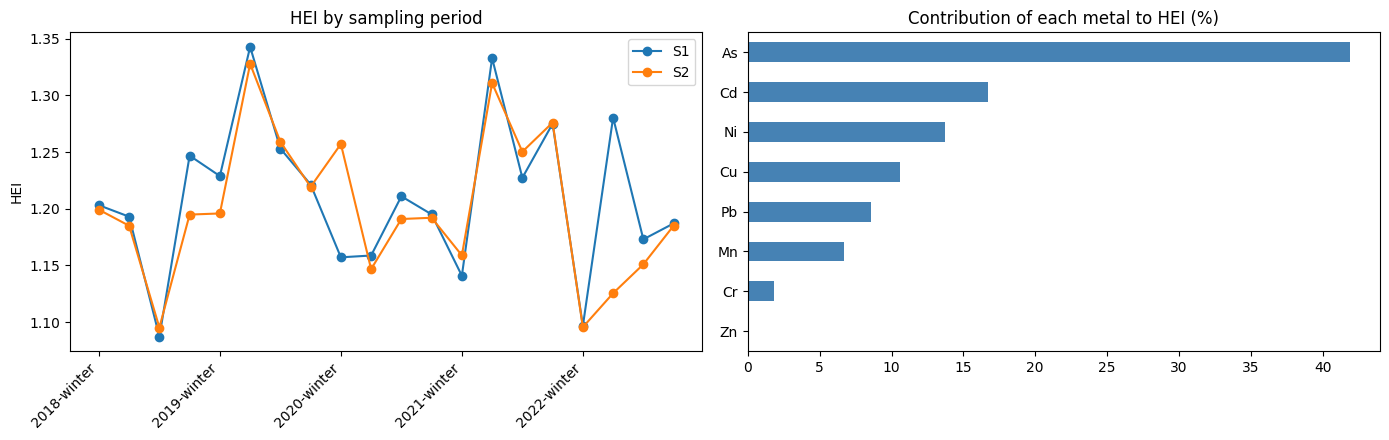

In [15]:
result["Date"] = result["Year"].astype(str) + "-" + result["Month"]
order = result["Date"].unique()

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for site, g in result.groupby("Site"):
    ax[0].plot(g["Date"], g["HEI"], marker="o", label=site)
ax[0].set_title("HEI by sampling period"); ax[0].set_ylabel("HEI")
ax[0].set_xticks(range(0, len(order), 4)); ax[0].set_xticklabels(order[::4], rotation=45, ha="right")
ax[0].legend()

contrib.sort_values().plot.barh(ax=ax[1], color="steelblue")
ax[1].set_title("Contribution of each metal to HEI (%)")
plt.tight_layout(); plt.show()

## 6. Check against the HEI column already in `Pollution_Indices.xls`

The source file already contains an HEI column. It is compared here with the value recalculated above.

In [16]:
hei_col = names[names == "HEI"].index[0]
file_hei = raw.iloc[2:, hei_col].astype(float).reset_index(drop=True)

check = pd.DataFrame({
    "Site": result["Site"], "Year": result["Year"], "Month": result["Month"],
    "HEI (recalculated)": result["HEI"].round(6),
    "HEI (in file)": file_hei,
})
check["Difference"] = (check["HEI (in file)"] - check["HEI (recalculated)"]).round(6)
print("Unique differences:", check["Difference"].unique())
check.head()

Unique differences: [2.]


,Site,Year,Month,HEI (recalculated),HEI (in file),Difference
0,S1,2018,winter,1.20308,3.20308,2.0
1,S1,2018,spring,1.19296,3.19296,2.0
2,S1,2018,summer,1.08718,3.08718,2.0
3,S1,2018,autumn,1.24681,3.24681,2.0
4,S1,2019,winter,1.22880,3.22880,2.0


**Result:** the HEI stored in the `.xls` file is larger than the sum of the eight *Mi/MACi* ratios by exactly **2.0** in every row, while the ratio columns themselves match. The recalculated HEI above (sum of the 8 ratios) is the correct value; the offset in the file most likely comes from a formula range that includes extra cells.

## 7. Export

In [17]:
out = Path("HEI_results.xlsx")
with pd.ExcelWriter(out) as w:
    result.drop(columns="Date").round(6).to_excel(w, sheet_name="HEI_all_samples", index=False)
    by_site.to_excel(w, sheet_name="Summary_by_site")
    by_year.to_excel(w, sheet_name="Mean_by_year")
    MAC.to_frame().to_excel(w, sheet_name="MAC_used")
print("Saved:", out.resolve())

Saved: C:\Users\HP\heavy_metal_pollution\HEI_results.xlsx
